Implement Agglomerative hierarchical clustering algorithm to predict the quality of wine. Use Wine
Quality dataset from UCI Machine Learning repository.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load datasets

In [5]:
red = pd.read_csv("C:/Users/PRANAV/Downloads/wine/winequality-red.csv", sep=";")

In [6]:
white = pd.read_csv("C:/Users/PRANAV/Downloads/wine/winequality-white.csv", sep=";")

## Add type column

In [7]:
red["type"] = "red"
white["type"] = "white"

## Combine datasets

In [8]:
df = pd.concat([red, white], axis=0)

In [9]:
df.reset_index(drop=True, inplace=True)

## Convert categorical to numeric

In [10]:
df["type"] = df["type"].map({"red": 0, "white": 1})

## Split features and target

In [11]:
x = df.drop("quality", axis=1)
y = df["quality"]

## Feature scaling

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
sc = StandardScaler()

In [14]:
x_scaled = sc.fit_transform(x)

## Apply Agglomerative Clustering

In [15]:
from sklearn.cluster import AgglomerativeClustering

In [16]:
agg = AgglomerativeClustering(n_clusters=2, linkage='ward')

In [17]:
clusters = agg.fit_predict(x_scaled)

## Add cluster column

In [18]:
df["Cluster"] = clusters

## Evaluate using Silhouette Score

In [19]:
from sklearn.metrics import silhouette_score
score = silhouette_score(x_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.3375647543010935


## Dendrogram 

In [20]:
from scipy.cluster.hierarchy import linkage, dendrogram

In [21]:
link = linkage(x_scaled[:500], method='ward')

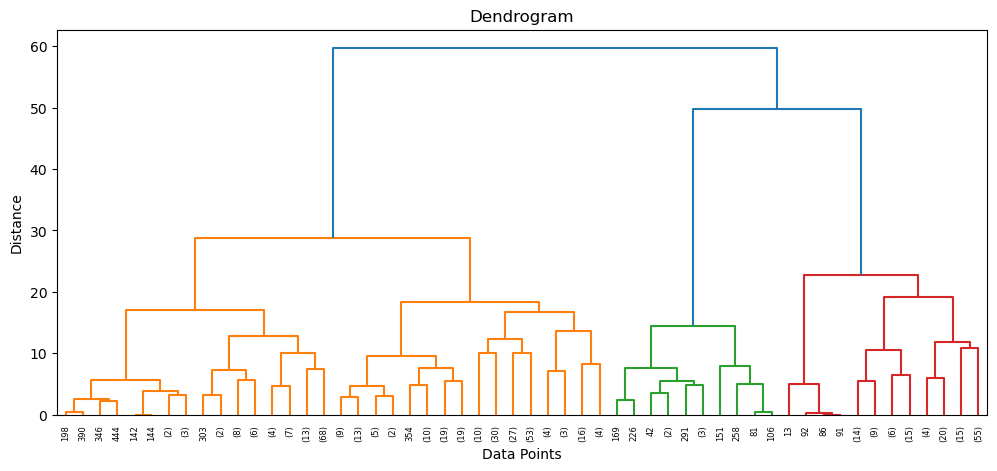

In [22]:
plt.figure(figsize=(12,5))
dendrogram(link, truncate_mode='level', p=5)
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

## PCA Visualization

In [23]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

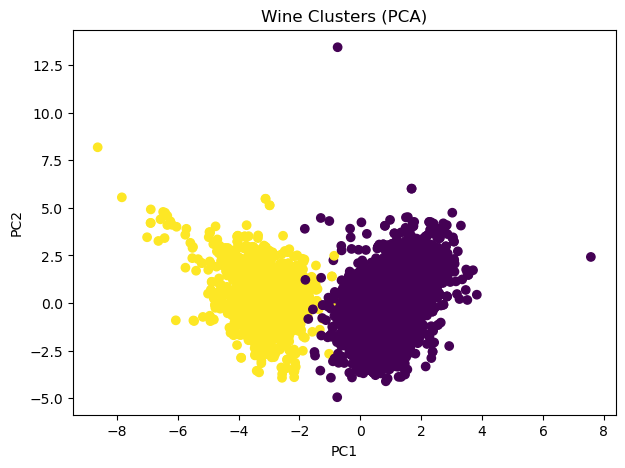

In [24]:
plt.figure(figsize=(7,5))
plt.scatter(x_pca[:,0], x_pca[:,1], c=df["Cluster"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Wine Clusters (PCA)")
plt.show()